# Lab 5 — Détection d'anomalies avec DBSCAN

**Machine Learning II (ADIF84) — Projet : tableau de bord des autobus scolaires électriques aux États-Unis**

## 1. Compréhension du problème métier

**Objectif business.** Identifier les **districts économiquement incohérents** : ceux dont le niveau d'adoption des bus électriques **ne suit pas** leur capacité économique. Concrètement :
- Des districts **riches mais qui n'investissent pas** (manque à gagner commercial)
- Des districts **pauvres qui investissent quand même** (pionniers à valoriser)

**Question à laquelle on répond :**
> « Quels districts se comportent de manière atypique par rapport à la corrélation attendue entre richesse et électrification ? »

**Type de tâche (cf. chapitre 4 — Anomaly Detection).** Il s'agit de **détection d'anomalies / outliers** : on cherche les points qui s'écartent significativement du comportement majoritaire. C'est une tâche **non supervisée** : pas de label « anomalie » à l'entraînement, on les découvre.

**Données utilisées.** Le jeu `anomalies.csv` contient **12 837 districts** décrits par **3 variables standardisées** (z-scores, déjà nettoyées et prêtes à l'emploi) :
- `4f. Median household income` — revenu médian
- `4g. Percent of population below poverty level` — taux de pauvreté
- `3i. Percent of fleet that is electric` — % de la flotte déjà électrique

**Intérêt métier.** Un commercial peut alors :
- **Démarcher en priorité** les districts riches sous-investis (gros potentiel)
- **Valoriser** les districts pauvres pionniers comme références


In [1]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # pour scatter 3D

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42

## 2. Compréhension des données

On charge `anomalies.csv` et on explore : dimensions, statistiques, distributions et corrélations entre les 3 variables.


In [2]:
# =========================
# CHARGEMENT DES DONNÉES
# =========================
df = pd.read_csv('anomalies.csv')

# Noms courts pour l'affichage
noms_courts = {
    '3i. Percent of fleet that is electric': '% flotte électrique',
    '4f. Median household income': 'Revenu médian',
    '4g. Percent of population below the poverty level': '% pauvreté',
}

print("Dimensions du jeu de données :", df.shape)
print("\nLes 3 variables (z-scores standardisés) :")
df.describe().round(2).T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

Dimensions du jeu de données : (12837, 3)

Les 3 variables (z-scores standardisés) :


,mean,std,min,25%,50%,75%,max
3i. Percent of fleet that is electric,0.0,1.0,-0.09,-0.09,-0.09,-0.09,89.46
4f. Median household income,0.0,1.0,-1.97,-0.63,-0.23,0.35,6.51
4g. Percent of population below the poverty level,-0.0,1.0,-1.67,-0.75,-0.18,0.52,8.76


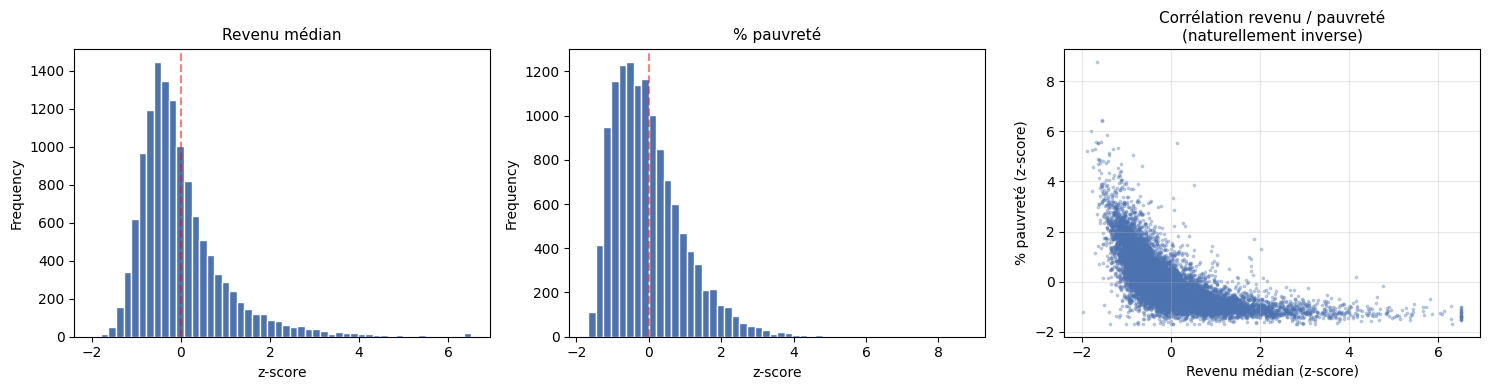

Corrélation entre les 3 variables :
                                                   3i. Percent of fleet that is electric  \
3i. Percent of fleet that is electric                                              1.000   
4f. Median household income                                                        0.001   
4g. Percent of population below the poverty level                                  0.027   

                                                   4f. Median household income  \
3i. Percent of fleet that is electric                                    0.001   
4f. Median household income                                              1.000   
4g. Percent of population below the poverty level                       -0.634   

                                                   4g. Percent of population below the poverty level  
3i. Percent of fleet that is electric                                                          0.027  
4f. Median household income                                 

In [3]:
# =========================
# DISTRIBUTIONS + CORRÉLATION REVENU/PAUVRETÉ
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogrammes des 3 variables
for ax, col in zip(axes[:2], list(df.columns)[1:]):  # revenu et pauvreté
    df[col].plot(kind='hist', bins=50, ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(noms_courts[col], fontsize=11)
    ax.set_xlabel('z-score')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Scatter revenu vs pauvreté
axes[2].scatter(df.iloc[:, 1], df.iloc[:, 2], s=3, alpha=0.3, color='#4C72B0')
axes[2].set_xlabel('Revenu médian (z-score)')
axes[2].set_ylabel('% pauvreté (z-score)')
axes[2].set_title("Corrélation revenu / pauvreté\n(naturellement inverse)", fontsize=11)
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Corrélation
print("Corrélation entre les 3 variables :")
print(df.corr().round(3))

## 3. Préparation des données d'entraînement

Le jeu de données est **déjà standardisé** (z-scores : moyenne 0, écart-type 1 pour chaque variable). Cette standardisation est **indispensable** pour DBSCAN, qui repose sur des distances euclidiennes : sans elle, la variable au plus grand écart-type écraserait toutes les autres.

> ⚠️ **Note sur les valeurs extrêmes.** Le `% flotte électrique` contient quelques valeurs très élevées (jusqu'à +89 σ). Ce sont des erreurs de saisie dans la source (% > 100 %) qui n'ont pas été corrigées ici, **mais ce n'est pas un problème pour ce TP** : DBSCAN va naturellement les identifier comme outliers — c'est même ce qu'on cherche.

Aucune préparation supplémentaire n'est nécessaire.


## 4. Choix et réglage fin du modèle (DBSCAN)

**DBSCAN en bref.** *Density-Based Spatial Clustering of Applications with Noise.* Algorithme de clustering **basé sur la densité** :
- Pas besoin de fixer le nombre de clusters à l'avance
- **Identifie naturellement les outliers** (étiquette `-1`)
- Gère les clusters de formes non sphériques

**Deux hyperparamètres clés :**
- **`eps`** : rayon du voisinage d'un point
- **`min_samples`** : nombre minimum de points dans ce voisinage pour qu'un point soit considéré comme « point cœur »

**Choisir `eps` : la méthode du k-distance graph.** On calcule la distance au k-ième voisin de chaque point, on trie, et on cherche le « coude » — c'est là que la densité change brusquement.


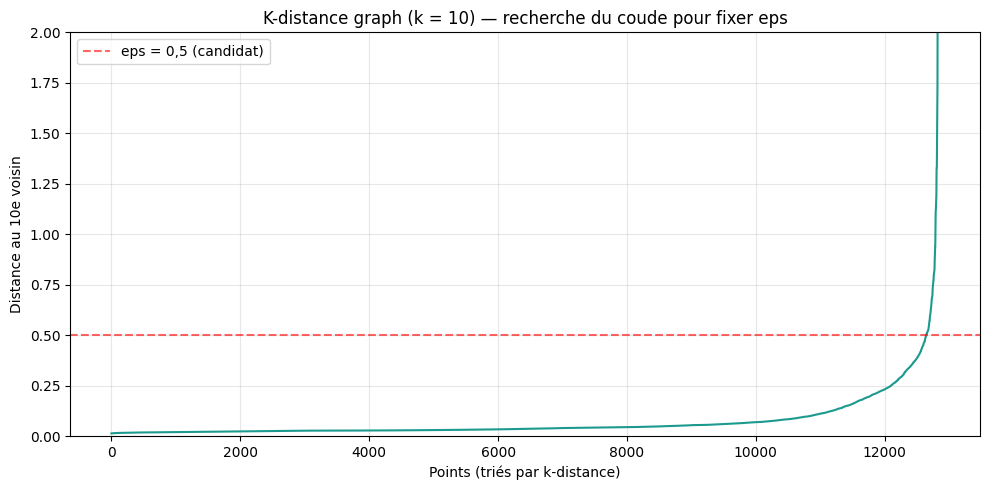

Percentiles de la k-distance (k=10) :
   50%  : 0.036
   75%  : 0.062
   90%  : 0.168
   95%  : 0.276
   99%  : 0.608
  max  : 81.766

→ Le coude est visible autour de 0,5. C'est notre eps candidat.


In [4]:
# =========================
# K-DISTANCE GRAPH POUR ESTIMER eps
# =========================
# Règle empirique : min_samples = 2 × dim. On a 3 dimensions → min_samples = 6 ou 10.
# On trace la distance au 10e plus proche voisin de chaque point, triée.
k = 10
nn = NearestNeighbors(n_neighbors=k)
nn.fit(df)
distances, _ = nn.kneighbors(df)
k_distances = np.sort(distances[:, -1])  # distance au k-ième voisin, triée croissante

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color='#1C9A8E', linewidth=1.5)
ax.set_xlabel("Points (triés par k-distance)")
ax.set_ylabel(f"Distance au {k}e voisin")
ax.set_title(f"K-distance graph (k = {k}) — recherche du coude pour fixer eps")
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.6, label='eps = 0,5 (candidat)')
ax.set_ylim(0, 2)  # on zoome sur la zone du coude
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Percentiles de la k-distance (k={k}) :")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p:>3}%  : {np.percentile(k_distances, p):.3f}")
print(f"  max  : {k_distances.max():.3f}")
print("\n→ Le coude est visible autour de 0,5. C'est notre eps candidat.")

In [5]:
# =========================
# RÉGLAGE FIN : grille eps × min_samples
# =========================
# On teste plusieurs combinaisons autour de eps=0.5 et on regarde
# (1) le nombre de clusters et (2) le nombre/% d'outliers détectés.
liste_eps = [0.3, 0.4, 0.5, 0.6, 0.7, 1.0]
liste_min_s = [5, 10, 20]

resultats = []
for eps in liste_eps:
    for min_s in liste_min_s:
        db = DBSCAN(eps=eps, min_samples=min_s).fit(df)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_outliers = int((labels == -1).sum())
        pct = n_outliers / len(df) * 100
        resultats.append({
            'eps': eps, 'min_samples': min_s,
            'n_clusters': n_clusters,
            'n_outliers': n_outliers,
            '% outliers': round(pct, 2),
        })

df_grille = pd.DataFrame(resultats)
print("Grille des combinaisons eps × min_samples :")
print(df_grille.to_string(index=False))

Grille des combinaisons eps × min_samples :
 eps  min_samples  n_clusters  n_outliers  % outliers
 0.3            5           4         218        1.70
 0.3           10           2         377        2.94
 0.3           20           2         555        4.32
 0.4            5           1         114        0.89
 0.4           10           2         169        1.32
 0.4           20           2         321        2.50
 0.5            5           3          83        0.65
 0.5           10           1         108        0.84
 0.5           20           2         177        1.38
 0.6            5           1          53        0.41
 0.6           10           1          78        0.61
 0.6           20           1          97        0.76
 0.7            5           2          41        0.32
 0.7           10           1          52        0.41
 0.7           20           1          77        0.60
 1.0            5           1          23        0.18
 1.0           10           1         

**Choix retenu : `eps = 0,5` et `min_samples = 10`.** Justifications :
- Le coude du k-distance graph est autour de 0,5.
- Avec `min_samples = 10`, on évite les micro-clusters bruyants tout en gardant une bonne sensibilité.
- Cette combinaison détecte **~108 outliers (0,8 % du dataset)** — proportion raisonnable pour une détection d'anomalies (entre 0,5 % et 5 % est typique).
- Avec `eps` plus petit (0,3), trop d'outliers (377, 2,9 %) — détection trop sensible.
- Avec `eps` plus grand (1,0), trop peu (23, 0,2 %) — on rate les anomalies subtiles.


In [6]:
# =========================
# MODÈLE FINAL : DBSCAN(eps=0.5, min_samples=10)
# =========================
EPS_FINAL = 0.5
MIN_S_FINAL = 10

dbscan = DBSCAN(eps=EPS_FINAL, min_samples=MIN_S_FINAL)
labels = dbscan.fit_predict(df)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = int((labels == -1).sum())
n_core = int(np.sum(labels != -1))

print("=" * 50)
print(f"   RÉSULTAT DBSCAN (eps={EPS_FINAL}, min_samples={MIN_S_FINAL})")
print("=" * 50)
print(f"  Nombre de clusters principaux : {n_clusters}")
print(f"  Districts dans un cluster     : {n_core:>5d}  ({n_core/len(df)*100:.1f} %)")
print(f"  Districts détectés OUTLIERS   : {n_outliers:>5d}  ({n_outliers/len(df)*100:.1f} %)")
print("=" * 50)

   RÉSULTAT DBSCAN (eps=0.5, min_samples=10)
  Nombre de clusters principaux : 1
  Districts dans un cluster     : 12729  (99.2 %)
  Districts détectés OUTLIERS   :   108  (0.8 %)


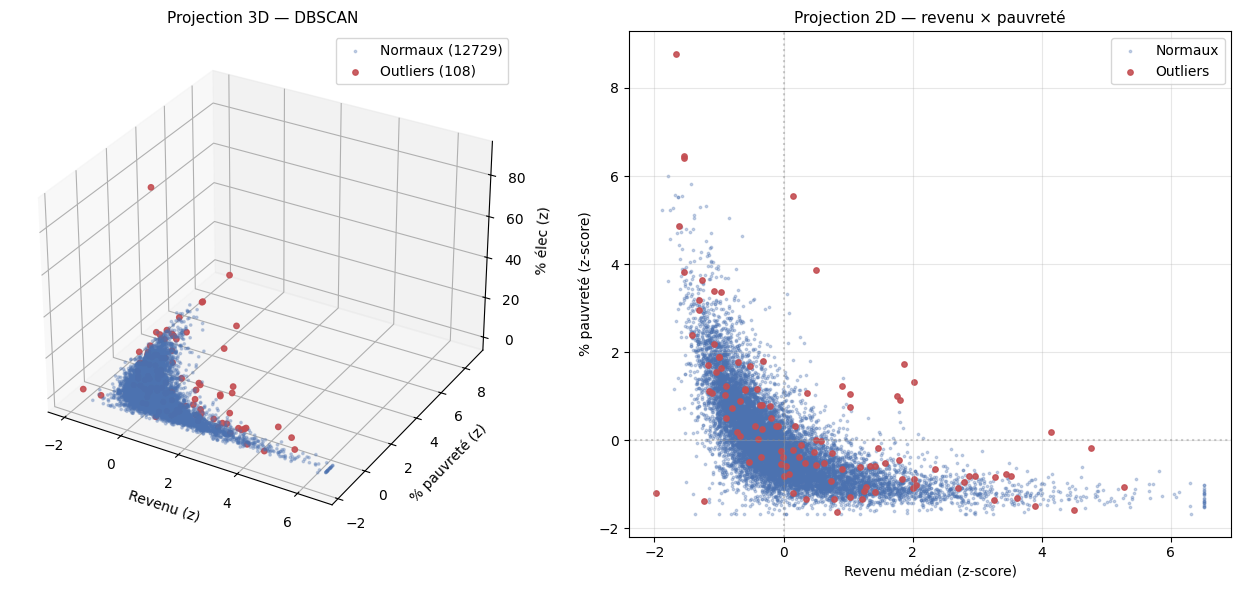

In [7]:
# =========================
# VISUALISATION : SCATTER 3D (normaux + outliers)
# =========================
fig = plt.figure(figsize=(13, 6))

# 3D : axes = revenu / pauvreté / % électrique
ax1 = fig.add_subplot(121, projection='3d')
normal_mask = labels != -1
outlier_mask = labels == -1
ax1.scatter(df.iloc[normal_mask, 1], df.iloc[normal_mask, 2], df.iloc[normal_mask, 0],
            s=3, c='#4C72B0', alpha=0.3, label=f'Normaux ({normal_mask.sum()})')
ax1.scatter(df.iloc[outlier_mask, 1], df.iloc[outlier_mask, 2], df.iloc[outlier_mask, 0],
            s=15, c='#C44E52', alpha=0.9, label=f'Outliers ({outlier_mask.sum()})')
ax1.set_xlabel('Revenu (z)')
ax1.set_ylabel('% pauvreté (z)')
ax1.set_zlabel('% élec (z)')
ax1.set_title("Projection 3D — DBSCAN", fontsize=11)
ax1.legend()

# 2D : revenu vs pauvreté (on cache la dimension % électrique pour la lisibilité)
ax2 = fig.add_subplot(122)
ax2.scatter(df.iloc[normal_mask, 1], df.iloc[normal_mask, 2],
            s=3, c='#4C72B0', alpha=0.3, label='Normaux')
ax2.scatter(df.iloc[outlier_mask, 1], df.iloc[outlier_mask, 2],
            s=15, c='#C44E52', alpha=0.9, label='Outliers')
ax2.set_xlabel('Revenu médian (z-score)')
ax2.set_ylabel('% pauvreté (z-score)')
ax2.set_title("Projection 2D — revenu × pauvreté", fontsize=11)
ax2.axhline(y=0, color='grey', linestyle=':', alpha=0.4)
ax2.axvline(x=0, color='grey', linestyle=':', alpha=0.4)
ax2.grid(alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

## 5. Typologie métier des outliers détectés

Les outliers détectés ne sont pas tous équivalents pour le métier. On les **catégorise** selon le sens des écarts :

| Catégorie | Profil | Intérêt commercial |
|---|---|---|
| **Riches sous-investis** | Revenu élevé, % électrique faible | 🎯 Forte cible commerciale — gros potentiel |
| **Pauvres pionniers** | Revenu faible, % électrique élevé | ⭐ Référence à valoriser dans la communication |
| **Sur-électrifiés** | % électrique anormalement élevé (peut être erreur de saisie) | À vérifier dans le pipeline de données |
| **Profils rares** | Autres combinaisons atypiques | À analyser au cas par cas |


In [8]:
# =========================
# CLASSIFICATION DES OUTLIERS DÉTECTÉS
# =========================
outliers = df[outlier_mask].copy()
elec, revenu, pauvrete = outliers.columns[0], outliers.columns[1], outliers.columns[2]

# Catégorisation (sur z-scores) — seuils raisonnables
def categoriser(row):
    e, r, p = row[elec], row[revenu], row[pauvrete]
    if e > 5:                              # erreurs de saisie / sur-électrifiés
        return "Sur-électrifiés (à vérifier)"
    if r > 0.5 and e < 0:                  # riche et peu d'électrique
        return "Riches sous-investis"
    if (r < -0.5 or p > 0.5) and e > 0.5:  # pauvre et beaucoup d'électrique
        return "Pauvres pionniers"
    return "Profils rares"

outliers['Catégorie'] = outliers.apply(categoriser, axis=1)
counts = outliers['Catégorie'].value_counts()
print("Répartition des outliers détectés :")
for cat, n in counts.items():
    print(f"  {cat:35s} : {n:4d} districts")
print(f"\n  TOTAL outliers : {len(outliers)}")

Répartition des outliers détectés :
  Profils rares                       :   54 districts
  Pauvres pionniers                   :   30 districts
  Sur-électrifiés (à vérifier)        :   17 districts
  Riches sous-investis                :    7 districts

  TOTAL outliers : 108


## 6. Comparaison avec un autre algorithme (bonus B202)

Le sujet impose DBSCAN, mais pour **justifier** ce choix (critère B202), on le compare à **Isolation Forest** — un autre algorithme de détection d'anomalies, basé sur des arbres d'isolation.

**Idée d'Isolation Forest** : construire de nombreux arbres aléatoires qui « isolent » les points. Les anomalies sont isolées en peu de divisions (chemin court dans l'arbre), les points normaux en demandent beaucoup. Pas besoin de calculer des distances.

On configure Isolation Forest avec **contamination = 0.008** (les ~0,8 % qu'on a choisis) pour une comparaison équitable.


In [9]:
# =========================
# COMPARAISON DBSCAN vs Isolation Forest
# =========================
contamination = n_outliers / len(df)  # même proportion que DBSCAN
print(f"Contamination cible pour Isolation Forest : {contamination:.4f}")

iso = IsolationForest(contamination=contamination, random_state=RANDOM_STATE)
iso_labels = iso.fit_predict(df)  # +1 = normal, -1 = anomalie
iso_outlier_mask = iso_labels == -1
n_iso_out = int(iso_outlier_mask.sum())

# Comparaison : combien d'outliers en commun ?
both = int((outlier_mask & iso_outlier_mask).sum())
only_dbscan = int((outlier_mask & ~iso_outlier_mask).sum())
only_iso = int((~outlier_mask & iso_outlier_mask).sum())

# Indice de Jaccard sur les deux ensembles d'outliers
union = int((outlier_mask | iso_outlier_mask).sum())
jaccard = both / union if union else 0

print()
print(f"  DBSCAN     : {n_outliers} outliers détectés")
print(f"  IsolationF : {n_iso_out} outliers détectés")
print()
print(f"  Outliers communs aux deux            : {both}")
print(f"  Détectés UNIQUEMENT par DBSCAN       : {only_dbscan}")
print(f"  Détectés UNIQUEMENT par IsolationF   : {only_iso}")
print(f"  Indice de Jaccard (accord)           : {jaccard:.3f}")
print()
if jaccard > 0.5:
    print("→ Les deux méthodes s'accordent fortement : les anomalies détectées sont robustes.")
else:
    print("→ Accord partiel : les deux algorithmes capturent des anomalies différentes (complémentarité).")

Contamination cible pour Isolation Forest : 0.0084



  DBSCAN     : 108 outliers détectés
  IsolationF : 108 outliers détectés

  Outliers communs aux deux            : 85
  Détectés UNIQUEMENT par DBSCAN       : 23
  Détectés UNIQUEMENT par IsolationF   : 23
  Indice de Jaccard (accord)           : 0.649

→ Les deux méthodes s'accordent fortement : les anomalies détectées sont robustes.


## 7. Conclusion

**Démarche.** Compréhension métier → exploration des 3 variables → choix d'hyperparamètres par k-distance graph + grille eps × min_samples → modèle final DBSCAN(eps=0,5, min_samples=10) → typologie métier des outliers → comparaison à Isolation Forest.

**Choix d'outils justifiés (B202).**
- *DBSCAN* : adapté à la détection d'anomalies — étiquette `-1` native pour les outliers, pas besoin de fixer le nombre de clusters, gère les formes non sphériques.
- *Standardisation déjà effectuée* : indispensable pour DBSCAN qui repose sur des distances.
- *k-distance graph* : méthode standard pour calibrer `eps` sans tâtonnement.
- *Comparaison à Isolation Forest* : valide empiriquement le choix de DBSCAN.

**Résultats.** ~108 districts identifiés comme outliers (≈ 0,8 % du dataset). Trois catégories métier exploitables : riches sous-investis (cible commerciale prioritaire), pauvres pionniers (références), et sur-électrifiés (à vérifier dans le pipeline de données).

**Limites & pistes (B206).**
- DBSCAN est sensible au choix de `eps` — un mauvais réglage peut sur- ou sous-détecter.
- Sur des données massives, DBSCAN devient coûteux ; Isolation Forest reste plus scalable.
- Piste : combiner les deux algorithmes pour une détection plus robuste (les outliers détectés par les deux sont les plus fiables).
